In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# https://www.kaggle.com/competitions/tweet-sentiment-extraction/overview
# 3 emotions, approx 30k labelled tweets
df_train = pd.read_csv("/content/train.csv",encoding='ISO-8859-1',header=None)

In [ ]:
df_train.head()

,0,1,2,3
0,textID,text,selected_text,sentiment
1,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
2,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
3,088c60f138,my boss is bullying me...,bullying me,negative
4,9642c003ef,what interview! leave me alone,leave me alone,negative


In [5]:
df_train.drop(columns=[2,0],inplace=True)

In [ ]:
df_train.head()

,1,3
0,text,sentiment
1,"I`d have responded, if I were going",neutral
2,Sooo SAD I will miss you here in San Diego!!!,negative
3,my boss is bullying me...,negative
4,what interview! leave me alone,negative


In [6]:
df_test = pd.read_csv("/content/test.csv",encoding='ISO-8859-1',header=None)

In [7]:
df_test.drop(columns=[0],inplace=True)

In [ ]:
df_test.tail(100)

,1,2
3435,awww! you like anne curtis too tho rite?? it`...,neutral
3436,Now have windows 7 up and running....very very...,positive
3437,"look up our youtube JessAndNicoleMusic, we are...",neutral
3438,I need a break! I NEED KITKAT! haha!,positive
3439,oh that totally works too,positive
...,...,...
3530,"its at 3 am, im very tired but i can`t sleep ...",negative
3531,All alone in this old house again. Thanks for...,positive
3532,I know what you mean. My little dog is sinkin...,negative
3533,_sutra what is your next youtube video gonna b...,positive


In [8]:
df = pd.concat([df_train, df_test])

In [9]:
df.drop(columns=[2],inplace=True)

In [10]:
df = df.drop([df.index[0]])

In [ ]:
df.head(20)

,1,3
1,"I`d have responded, if I were going",neutral
2,Sooo SAD I will miss you here in San Diego!!!,negative
3,my boss is bullying me...,negative
4,what interview! leave me alone,negative
5,"Sons of ****, why couldn`t they put them on t...",negative
6,http://www.dothebouncy.com/smf - some shameles...,neutral
7,2am feedings for the baby are fun when he is a...,positive
8,Soooo high,neutral
9,Both of you,neutral
10,Journey!? Wow... u just became cooler. hehe....,positive


In [ ]:
len(df)

31015

In [ ]:
# Before moving forward with a dataset:
# Confirm if country is not available
# Confirm if it was filtered on any search phrase
# Confirm if retweets are included, if yes, drop them
# Dropn NANs/impute as appropriate

In [11]:
df.columns = ['text','Sentiment']

In [ ]:
df.head()

,text,Sentiment
1,"I`d have responded, if I were going",neutral
2,Sooo SAD I will miss you here in San Diego!!!,negative
3,my boss is bullying me...,negative
4,what interview! leave me alone,negative
5,"Sons of ****, why couldn`t they put them on t...",negative


In [10]:
df.isna().sum().sum()

3535

In [12]:
df.dropna(axis=0,inplace=True)

In [13]:
# Function to Clean the Tweet.

import re
def clean_tweet(tweet):
    return ' '.join(re.sub('(\\\\n)|(b\"[^0-9A-Za-z A-Za-z0-9 \t]+)|(b\'[^0-9A-Za-z]+)|(b\"[A-Za-z0-9]+)|(b\'[A-Za-z0-9]+)|(b\'#[A-Za-z0-9]+)|(b\'@[A-Za-z0-9]+)|(\\\\x[A-Za-z0-9]+)|(@[A-Za-z0-9]+)|([^0-9A-Za-z \t])|(\w+:\/\/\S+)|([RT])', ' ', str(tweet).lower()).split())

# We only want the Text so :

# (@[A-Za-z0-9]+)   : Delete Anything like @hello @Letsupgrade etc
# ([^0-9A-Za-z \t]) : Delete everything other than text,number,space,tabspace
# (\w+:\/\/\S+)     : Delete https://
# ([RT]) : Remove "RT" from the tweet
# \xe2\x80\x9cguaran : Remove such tags
# b'@thedailybeast : Remove such words : SS - check if we can only remove the b' prefix instead of full word
# SS - Check if apostrophe can be retained eg: hadn't currently becomes hadn t

In [14]:
# Call function to get Clean tweets
df["CleanTweet"] = df['text'].apply(lambda x : clean_tweet(x))


In [ ]:
df.head(100)

,text,Sentiment,CleanTweet
1,"I`d have responded, if I were going",neutral,i d have responded if i were going
2,Sooo SAD I will miss you here in San Diego!!!,negative,sooo sad i will miss you here in san diego
3,my boss is bullying me...,negative,my boss is bullying me
4,what interview! leave me alone,negative,what interview leave me alone
5,"Sons of ****, why couldn`t they put them on t...",negative,sons of why couldn t they put them on the rele...
...,...,...,...
96,Happy Mothers day to all you Mums out there,positive,happy mothers day to all you mums out there
97,"CASEY`S GONE?!?! BUT WHY?! So, she piddled a ...",negative,casey s gone but why so she piddled a little o...
98,hemp cloth is marvelous but unfortunately no,negative,hemp cloth is marvelous but unfortunately no
99,Gonna read a story bout adam lambert online th...,neutral,gonna read a story bout adam lambert online th...


In [ ]:
#df["CleanTweet"] = df["CleanTweet"].apply(lambda x: ' '.join([w for w in x.split() if len(w)>1]))

In [15]:
df[df.CleanTweet.eq("")]

,text,Sentiment,CleanTweet
8121,****,negative,
26006,?,neutral,


In [16]:
df.drop(df.index[df.CleanTweet.eq("")], inplace=True)

In [ ]:
# Check Summary of Random Record
n = 23000
print("Original tweet:\n",df['text'][n])
print()
print("Clean tweet:\n",df['CleanTweet'][n])
print()
print("Sentiment of the tweet:\n",df['Sentiment'][n])

Original tweet:
  Oh, I is dubbed Breesaholic Insomniac #2  *feels special* oh! must add third Angel drink to post

Clean tweet:
 oh i is dubbed breesaholic insomniac 2 feels special oh must add third angel drink to post

Sentiment of the tweet:
 neutral


In [ ]:
# Overall Summary

print("Total Tweets Extracted Are {}".format(len(df.text)))
print("Total Positive Tweets are : {}".format(len(df[df["Sentiment"]=='positive'])))
print("Total Negative Tweets are : {}".format(len(df[df["Sentiment"]=='negative'])))
print("Total Neutral Tweets are : {}".format(len(df[df["Sentiment"]=='neutral'])))

Total Tweets Extracted Are 27478
Total Positive Tweets are : 8582
Total Negative Tweets are : 7780
Total Neutral Tweets are : 11116


In [ ]:
df["Sentiment"].value_counts()

neutral     11116
positive     8582
negative     7780
Name: Sentiment, dtype: int64

/usr/local/lib/python3.7/dist-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


Text(0.5, 1.0, 'Summary of Counts for Total tweets')

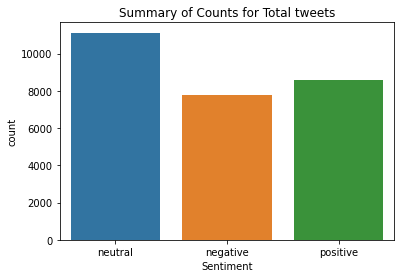

In [ ]:
#sns.countplot(df["Sentiment"],facecolor=(0, 0, 0, 0),linewidth=5,edgecolor=sns.color_palette("dark", 3))
sns.countplot(df["Sentiment"])
plt.title("Summary of Counts for Total tweets")

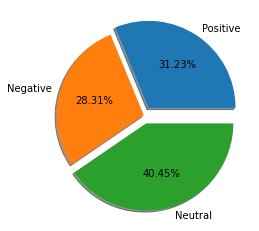

In [ ]:
# Piechart 
#string, used to label the wedges with their numeric value. The label will be placed inside the wedge. The format string will be fmt%pct.

a=len(df[df["Sentiment"]=='positive'])
b=len(df[df["Sentiment"]=='negative'])
c=len(df[df["Sentiment"]=='neutral'])
d=np.array([a,b,c])
explode = (0.1, 0.0, 0.1)
plt.pie(d,shadow=True,explode=explode,labels=["Positive","Negative","Neutral"],autopct='%1.2f%%');

In [17]:
#Tokenization
df['TokenizedTweet'] = df['CleanTweet'].apply(lambda x: x.split())
df.head()


,text,Sentiment,CleanTweet,TokenizedTweet
1,"I`d have responded, if I were going",neutral,i d have responded if i were going,"[i, d, have, responded, if, i, were, going]"
2,Sooo SAD I will miss you here in San Diego!!!,negative,sooo sad i will miss you here in san diego,"[sooo, sad, i, will, miss, you, here, in, san,..."
3,my boss is bullying me...,negative,my boss is bullying me,"[my, boss, is, bullying, me]"
4,what interview! leave me alone,negative,what interview leave me alone,"[what, interview, leave, me, alone]"
5,"Sons of ****, why couldn`t they put them on t...",negative,sons of why couldn t they put them on the rele...,"[sons, of, why, couldn, t, they, put, them, on..."


In [18]:
from nltk.stem.porter import *
stemmer = PorterStemmer()

tokenized_tweet = df['TokenizedTweet'].apply(lambda x: [stemmer.stem(i) for i in x]) # stemming
tokenized_tweet.head()

1               [i, d, have, respond, if, i, were, go]
2    [sooo, sad, i, will, miss, you, here, in, san,...
3                            [my, boss, is, bulli, me]
4                    [what, interview, leav, me, alon]
5    [son, of, whi, couldn, t, they, put, them, on,...
Name: TokenizedTweet, dtype: object

In [19]:
df['StemmedTweet']= tokenized_tweet.apply(lambda x: ' '.join(wrd for wrd in x))


In [ ]:
df.head()

,text,Sentiment,CleanTweet,TokenizedTweet,StemmedTweet
1,"I`d have responded, if I were going",neutral,i d have responded if i were going,"[i, d, have, responded, if, i, were, going]",i d have respond if i were go
2,Sooo SAD I will miss you here in San Diego!!!,negative,sooo sad i will miss you here in san diego,"[sooo, sad, i, will, miss, you, here, in, san,...",sooo sad i will miss you here in san diego
3,my boss is bullying me...,negative,my boss is bullying me,"[my, boss, is, bullying, me]",my boss is bulli me
4,what interview! leave me alone,negative,what interview leave me alone,"[what, interview, leave, me, alone]",what interview leav me alon
5,"Sons of ****, why couldn`t they put them on t...",negative,sons of why couldn t they put them on the rele...,"[sons, of, why, couldn, t, they, put, them, on...",son of whi couldn t they put them on the relea...


In [ ]:
# Add Lemmatization here
import nltk
nltk.download('omw-1.4')
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
lemmatizer = WordNetLemmatizer()
# Lemmatization
lemmatized_tweet = tokenized_tweet.apply(lambda x: [lemmatizer.lemmatize(i) for i in x if i not in set(stopwords.words('english'))])
lemmatized_tweet.head()

[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


1                               [respond, go]
2               [sooo, sad, miss, san, diego]
3                                [bos, bulli]
4                     [interview, leav, alon]
5    [son, whi, put, releas, alreadi, bought]
Name: TokenizedTweet, dtype: object

In [ ]:
df['LemmatizedTweet']= lemmatized_tweet.apply(lambda x: ' '.join(wrd for wrd in x))

In [ ]:
df.head()

,text,Sentiment,CleanTweet,TokenizedTweet,StemmedTweet,LemmatizedTweet
1,"I`d have responded, if I were going",neutral,i d have responded if i were going,"[i, d, have, responded, if, i, were, going]",i d have respond if i were go,respond go
2,Sooo SAD I will miss you here in San Diego!!!,negative,sooo sad i will miss you here in san diego,"[sooo, sad, i, will, miss, you, here, in, san,...",sooo sad i will miss you here in san diego,sooo sad miss san diego
3,my boss is bullying me...,negative,my boss is bullying me,"[my, boss, is, bullying, me]",my boss is bulli me,bos bulli
4,what interview! leave me alone,negative,what interview leave me alone,"[what, interview, leave, me, alone]",what interview leav me alon,interview leav alon
5,"Sons of ****, why couldn`t they put them on t...",negative,sons of why couldn t they put them on the rele...,"[sons, of, why, couldn, t, they, put, them, on...",son of whi couldn t they put them on the relea...,son whi put releas alreadi bought


In [20]:
#TFIDF  Vectorizer (add Count Vectorizer (Bag of Words) too if needed)
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer(max_df=0.90, min_df=2, max_features=10000, stop_words='english')
# TF-IDF feature matrix
tfidf = tfidf_vectorizer.fit_transform(df['StemmedTweet']).A

In [ ]:
df['Sentiment'].value_counts()

neutral     11116
positive     8582
negative     7780
Name: Sentiment, dtype: int64

In [21]:
#Emotion dictionary lookup
emotions_dict = {"negative":0, "neutral":2, "positive":4}
emotions_dict

def emo_lookup(emo):
  return emotions_dict[emo]

df['Label'] = df.Sentiment.apply(emo_lookup)

In [22]:
X = pd.DataFrame(tfidf)
X.values

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [23]:
y = df.Label
y.values

array([2, 0, 0, ..., 4, 4, 2])

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# splitting data into training and validation set
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y,random_state=42, test_size=0.2)

In [25]:
# Current F1 Score = 0.7062985404177087

lreg = LogisticRegression(max_iter=10000)


In [ ]:
lreg.fit(Xtrain, ytrain) # training the model

In [ ]:
ypred = lreg.predict(Xtest) # predicting on the validation set
f1_score(ytest, ypred,average='weighted')

0.6809530962006212

In [ ]:
accuracy_score(ytest,ypred)

0.6812227074235808

In [26]:
# Random Forest # Hanging for too long, something wrong
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)


In [ ]:
rf_model.fit(Xtrain, ytrain)
rf_model.score(Xtrain, ytrain), rf_model.score(Xtest, ytest)

In [ ]:
y_pred = rf_model.predict(Xtest)
accuracy_score(ytest,y_pred)

0.7043304221251819

In [ ]:
#Linear SVC
from sklearn.svm import LinearSVC

Lsvm = LinearSVC(random_state=0, tol=1e-5)
Lsvm.fit(Xtrain, ytrain)
Lsvm.score(Xtest, ytest)

0.6653930131004366

In [ ]:
y_pred = Lsvm.predict(Xtest)
accuracy_score(ytest,ypred)

0.6812227074235808

In [ ]:
!pip -qq install xgboost

In [ ]:
# xgb classifier
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb.fit(Xtrain, ytrain)
xgb.score(Xtest, ytest)

0.6431950509461426

In [ ]:
y_pred = xgb.predict(Xtest)
accuracy_score(ytest,y_pred)

0.6431950509461426

In [ ]:
!pip install catboost

In [ ]:
from catboost import CatBoostClassifier
catb = CatBoostClassifier()
catb.fit(Xtrain,
          ytrain,
          verbose=False)

In [ ]:
catb.score(Xtest,ytest)

0.6937772925764192

In [ ]:
y_pred = catb.predict(Xtest)
accuracy_score(ytest,y_pred)

0.6937772925764192

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
adab = AdaBoostClassifier(n_estimators=50,
                         learning_rate=0.5)
# Train Adaboost Classifer
adamodel = adab.fit(Xtrain, ytrain)

In [ ]:
adamodel.score(Xtest,ytest)

0.6328238719068413

In [ ]:
y_pred = adamodel.predict(Xtest)
accuracy_score(ytest,y_pred)

0.6328238719068413

In [ ]:
from sklearn.naive_bayes import MultinomialNB  
classifier = MultinomialNB()  
classifier.fit(Xtrain, ytrain)

MultinomialNB()

In [ ]:
ypred = classifier.predict(Xtest)

In [ ]:
f1_score(ytest,ypred,average='weighted')

0.6208324009314414

In [ ]:
accuracy_score(ytest,ypred)

0.62372634643377

In [27]:
# Voting classifer
from sklearn.ensemble import VotingClassifier
voting = VotingClassifier(estimators=[('lr',lreg),('rf_model', rf_model)], voting='soft')
voting = voting.fit(Xtrain, ytrain)

In [26]:
y_pred = voting.predict(Xtest)

In [ ]:
voting.score(Xtest,ytest)

0.7052401746724891

In [ ]:
accuracy_score(ytest,y_pred)

0.7052401746724891

In [ ]:
confusion_matrix(ytest,y_pred)

array([[ 938,  509,   97],
       [ 273, 1649,  293],
       [  71,  377, 1289]])

In [ ]:
classification_report(ytest,y_pred)

'              precision    recall  f1-score   support\n\n           0       0.73      0.61      0.66      1544\n           2       0.65      0.74      0.69      2215\n           4       0.77      0.74      0.75      1737\n\n    accuracy                           0.71      5496\n   macro avg       0.72      0.70      0.70      5496\nweighted avg       0.71      0.71      0.70      5496\n'

In [ ]:
from sklearn.metrics import balanced_accuracy_score
balanced_accuracy_score(ytest,y_pred)

0.6980221774307086

In [ ]:
y_pred

array([4, 4, 2, ..., 2, 2, 4])

In [ ]:
ytest

1590     4
10416    4
6563     2
2604     4
4005     2
        ..
15646    4
618      2
4506     2
26572    0
24839    4
Name: Label, Length: 5496, dtype: int64

In [28]:
ddf = pd.read_csv("/content/2020_Sep6_154k_hydrated_tweets.csv")

In [29]:
ddf.drop(columns=['id_str',"in_reply_to_screen_name","is_retweet"], inplace=True)

In [30]:
# Call function to get Clean tweets
ddf["CleanTweet"] = ddf['text'].apply(lambda x : clean_tweet(x))

In [31]:
ddf.drop(ddf.index[ddf.CleanTweet.eq("")], inplace=True)

In [31]:
ddf.isna().sum().sum()

0

In [32]:
ddf.dropna(axis=0,inplace=True)

In [35]:
ddf.isna().sum().sum()

0

In [36]:
len(ddf)

152629

In [33]:
ddf.to_csv("tweets_2020_ML_Voting_LR_RF_Sentiments.csv",index=False)

In [34]:
ddf_1 = ddf.iloc[:50000,:]
ddf_2 = ddf.iloc[50000:100000,:]
ddf_3 = ddf.iloc[100000:152629,:]

In [ ]:
ddf_3.head()

In [35]:
ddf_3['TokenizedTweet'] = ddf_3['CleanTweet'].apply(lambda x: x.split())

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.


In [36]:
tokenized_tweet = ddf_3['TokenizedTweet'].apply(lambda x: [stemmer.stem(i) for i in x]) # stemming

In [37]:
ddf_3['StemmedTweet']= tokenized_tweet.apply(lambda x: ' '.join(wrd for wrd in x))

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.


In [38]:
# TF-IDF feature matrix
ddf_tfidf = tfidf_vectorizer.transform(ddf_3['StemmedTweet']).A

In [39]:
XX = pd.DataFrame(ddf_tfidf)
XX.values

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [40]:
y_pred = voting.predict(XX)

In [40]:
y_pred.dtype

dtype('int64')

In [41]:
result = pd.DataFrame(y_pred,columns=['Label'])

In [ ]:
result

In [42]:
#Emotion dictionary lookup
reverse_emotions_dict = {0:"negative",1:"negative", 2:"neutral",3:"positive", 4:"positive"}
reverse_emotions_dict

def reverse_emo_lookup(emo):
  return reverse_emotions_dict[emo]

result['Sentiment'] = result.Label.apply(reverse_emo_lookup)

In [43]:
len(result)

50000

In [44]:
result.isna().sum().sum()

0

In [54]:
#result_1 = result

In [45]:
#result_2 = result

In [43]:
result_3 = result

In [44]:
result.to_csv("ypred_3_2020_ML_Voting_LR_RF_Sentiments.csv",index=False)

In [ ]:
final_result = pd.concat([result_1, result_2, result_3])

In [ ]:
final_result.to_csv("ypred_2020_ML_Voting_LR_RF_Sentiments.csv",index=False)

In [46]:
result_1 = pd.read_csv("/content/ypred_1_2020_ML_Voting_LR_RF_Sentiments.csv")

In [47]:
result_2 = pd.read_csv("/content/ypred_2_2020_ML_Voting_LR_RF_Sentiments.csv")

In [48]:
final_result2 = pd.concat([result_1, result_2, result_3])

In [49]:
final_result2.to_csv("ypred_final_2020_ML_Voting_LR_RF_Sentiments.csv",index=False)

In [50]:
len(final_result2)

152629

In [ ]:
# Function to analyze Sentiment using TextBlob

from textblob import TextBlob
def analyze_sentiment(tweet):
    analysis = TextBlob(tweet)
    if analysis.sentiment.polarity > 0:
        return 'Positive'
    elif analysis.sentiment.polarity == 0:
        return 'Neutral'
    else:
        return 'Negative'

In [ ]:
# Call function to get the Sentiments

df["TextBlobSentiment"] = df["StemmedTweet"].apply(lambda x : analyze_sentiment(x))
df.head(5)

,text,Sentiment,CleanTweet,TokenizedTweet,StemmedTweet,TextBlobSentiment
1,"I`d have responded, if I were going",neutral,i d have responded if i were going,"[i, d, have, responded, if, i, were, going]",i d have respond if i were go,Neutral
2,Sooo SAD I will miss you here in San Diego!!!,negative,sooo sad i will miss you here in san diego,"[sooo, sad, i, will, miss, you, here, in, san,...",sooo sad i will miss you here in san diego,Negative
3,my boss is bullying me...,negative,my boss is bullying me,"[my, boss, is, bullying, me]",my boss is bulli me,Neutral
4,what interview! leave me alone,negative,what interview leave me alone,"[what, interview, leave, me, alone]",what interview leav me alon,Neutral
5,"Sons of ****, why couldn`t they put them on t...",negative,sons of why couldn t they put them on the rele...,"[sons, of, why, couldn, t, they, put, them, on...",son of whi couldn t they put them on the relea...,Neutral


In [ ]:
!pip3 install vaderSentiment

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 125 kB 5.2 MB/s 


In [ ]:
# Function to analyze Sentiment using Vader

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

def analyze_sentiment_vader(tweet):
    analyzer = SentimentIntensityAnalyzer()
    analysis = analyzer.polarity_scores(tweet)
    # decide sentiment as positive, negative and neutral
    if analysis['compound'] >= 0.05 :
        return "Positive"
    elif analysis['compound'] <= - 0.05 :
        return "Negative"
    else :
        return "Neutral"

In [ ]:
# Call function to get the Sentiments using Vader

df["VaderSentiment"] = df["StemmedTweet"].apply(lambda x : analyze_sentiment_vader(x))

In [ ]:
!pip3 install flair

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 401 kB 4.5 MB/s 
     |████████████████████████████████| 4.9 MB 49.5 MB/s 
     |████████████████████████████████| 19.7 MB 1.4 MB/s 
     |████████████████████████████████| 788 kB 56.5 MB/s 
     |████████████████████████████████| 1.2 MB 65.2 MB/s 
     |████████████████████████████████| 53 kB 1.6 MB/s 
     |████████████████████████████████| 163 kB 67.4 MB/s 
     |████████████████████████████████| 1.6 MB 45.4 MB/s 
     |████████████████████████████████| 981 kB 62.2 MB/s 
     |████████████████████████████████| 46 kB 3.7 MB/s 
     |████████████████████████████████| 200 kB 61.6 MB/s 
     |████████████████████████████████| 62 kB 1.3 MB/s 
     |████████████████████████████████| 6.6 MB 38.6 MB/s 
  Created wheel for mpld3: filename=mpld3-0.3-py3-none-any.whl size=116702 sha256=d9817c1779c8af278bca3c38496cf1b99ff8520edb2e28aa67a4c2c21091fc51
  Store

In [ ]:
# Function to analyze Sentiment using Flair

from flair.models import TextClassifier
from flair.data import Sentence
classifier = TextClassifier.load('en-sentiment')
def analyze_sentiment_flair(tweet):
    sentence = Sentence(tweet)
    classifier.predict(sentence)
    if(sentence.labels[0].value == 'POSITIVE'):
      return 'Positive'
    else:
      return 'Negative'
    #return sentence.labels[0].value

2022-10-06 05:21:08,075 https://nlp.informatik.hu-berlin.de/resources/models/sentiment-curated-distilbert/sentiment-en-mix-distillbert_4.pt not found in cache, downloading to /tmp/tmpeymrids6


100%|██████████| 265512723/265512723 [00:13<00:00, 19745640.22B/s]

2022-10-06 05:21:21,918 copying /tmp/tmpeymrids6 to cache at /root/.flair/models/sentiment-en-mix-distillbert_4.pt


2022-10-06 05:21:23,213 removing temp file /tmp/tmpeymrids6
2022-10-06 05:21:23,459 loading file /root/.flair/models/sentiment-en-mix-distillbert_4.pt


Downloading:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/483 [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/232k [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
# Call function to get the Sentiments using Flair
df["FlairSentiment"] = df["CleanTweet"].apply(lambda x : analyze_sentiment_flair(x))
df.head(5)

,text,Sentiment,CleanTweet,TokenizedTweet,StemmedTweet,TextBlobSentiment,VaderSentiment,FlairSentiment
1,"I`d have responded, if I were going",neutral,i d have responded if i were going,"[i, d, have, responded, if, i, were, going]",i d have respond if i were go,Neutral,Neutral,Negative
2,Sooo SAD I will miss you here in San Diego!!!,negative,sooo sad i will miss you here in san diego,"[sooo, sad, i, will, miss, you, here, in, san,...",sooo sad i will miss you here in san diego,Negative,Negative,Positive
3,my boss is bullying me...,negative,my boss is bullying me,"[my, boss, is, bullying, me]",my boss is bulli me,Neutral,Neutral,Negative
4,what interview! leave me alone,negative,what interview leave me alone,"[what, interview, leave, me, alone]",what interview leav me alon,Neutral,Neutral,Negative
5,"Sons of ****, why couldn`t they put them on t...",negative,sons of why couldn t they put them on the rele...,"[sons, of, why, couldn, t, they, put, them, on...",son of whi couldn t they put them on the relea...,Neutral,Neutral,Positive


In [ ]:
df.head()

,text,Sentiment,CleanTweet,TokenizedTweet,StemmedTweet,TextBlobSentiment,VaderSentiment,FlairSentiment,Label
1,"I`d have responded, if I were going",neutral,i d have responded if i were going,"[i, d, have, responded, if, i, were, going]",i d have respond if i were go,2,Neutral,Negative,2
2,Sooo SAD I will miss you here in San Diego!!!,negative,sooo sad i will miss you here in san diego,"[sooo, sad, i, will, miss, you, here, in, san,...",sooo sad i will miss you here in san diego,0,Negative,Positive,0
3,my boss is bullying me...,negative,my boss is bullying me,"[my, boss, is, bullying, me]",my boss is bulli me,2,Neutral,Negative,0
4,what interview! leave me alone,negative,what interview leave me alone,"[what, interview, leave, me, alone]",what interview leav me alon,2,Neutral,Negative,0
5,"Sons of ****, why couldn`t they put them on t...",negative,sons of why couldn t they put them on the rele...,"[sons, of, why, couldn, t, they, put, them, on...",son of whi couldn t they put them on the relea...,2,Neutral,Positive,0


In [ ]:
#Emotion dictionary lookup
emotions_dict = {"Negative":0, "Neutral":2, "Positive":4}
emotions_dict

def emo_lookup(emo):
  return emotions_dict[emo]

In [ ]:
from sklearn.metrics import accuracy_score
df.TextBlobSentiment = df.TextBlobSentiment.apply(emo_lookup)

In [ ]:
accuracy_score(df.Label,df.TextBlobSentiment)

0.5236552878666569

In [ ]:
df.VaderSentiment = df.VaderSentiment.apply(emo_lookup)
accuracy_score(df.Label,df.VaderSentiment)

0.588470776621297

In [ ]:
df.FlairSentiment = df.FlairSentiment.apply(emo_lookup)
accuracy_score(df.Label,df.FlairSentiment)

0.4906470631050295